# Border-04-Deployment
## Edge AI-Based Acoustic Footstep Detection for Border Surveillance
### Notebook 04 · Quantisation-Aware Training · C Export · ESP32 Firmware · LoRa Protocol

**Pipeline:** EDA → Preprocessing → Training → **Deployment ← (you are here)**

**Problem from NB03:** INT8 post-training quantisation dropped accuracy by 12% (0.86 → 0.74)  
**Solution:** Quantisation-Aware Training (QAT) — simulate quantisation during training  
**Target:** INT8 acc ≥ 0.84 (< 2% drop from float32 baseline)

**Inputs:** `features_train.npz`, `features_val.npz`, `features_test.npz`, `border_model_int8.tflite`  
**Outputs:** `border_model_qat_int8.tflite`, `model_weights.h`, ESP32 `.ino` sketch, LoRa packet spec

In [10]:
!pip install -q tensorflow-model-optimization

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, time, struct, textwrap, json
warnings.filterwarnings("ignore")
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical
print(f"TensorFlow : {tf.__version__}")

# TensorFlow Model Optimization Toolkit (QAT)
import tensorflow_model_optimization as tfmot
print(f"TF-MOT     : {tfmot.__version__}")

from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH    = "/kaggle/input/datasets/katakuricharlotte/border-preprocessed-data/processed"
NB03_PATH    = "/kaggle/input/datasets/katakuricharlotte/border-nb03-models"   # NB03 saved models
WORKING_PATH = "/kaggle/working"
FIGURES_PATH = "/kaggle/working/figures"
FIRMWARE_PATH= "/kaggle/working/firmware"
os.makedirs(FIGURES_PATH,  exist_ok=True)
os.makedirs(FIRMWARE_PATH, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
CLASS_NAMES  = ["balastic", "footsteps", "noise"]
N_CLASSES    = 3
N_FEATURES   = 24
CLASS_COLORS = {"balastic": "#2196F3", "footsteps": "#FF9800", "noise": "#4CAF50"}
PALETTE      = [CLASS_COLORS[c] for c in CLASS_NAMES]

# ── Paper-ready plot styling ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#FFFFFF",
    "grid.linewidth": 1.2,
    "grid.alpha": 0.7,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#CCCCCC",
    "lines.linewidth": 1.8,
    "patch.linewidth": 0.5,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
})

def paper_axes(ax):
    ax.set_facecolor("#F8F9FA")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
        spine.set_linewidth(0.8)
    ax.grid(True, color="white", linewidth=1.2, alpha=0.7)
    ax.tick_params(colors="#444444")
    ax.title.set_color("#222222")
    ax.xaxis.label.set_color("#444444")
    ax.yaxis.label.set_color("#444444")
    return ax

print("✓ Environment ready")

TensorFlow : 2.19.0
TF-MOT     : 0.8.0
✓ Environment ready


In [12]:
def load_split(tag):
    d = np.load(f"{DATA_PATH}/features_{tag}.npz", allow_pickle=True)
    return d["X"].astype(np.float32), d["y_enc"].astype(np.int64), d["classes"]

X_train, y_train, label_names = load_split("train")
X_val,   y_val,   _           = load_split("val")
X_test,  y_test,  _           = load_split("test")

Y_train = to_categorical(y_train, N_CLASSES)
Y_val   = to_categorical(y_val,   N_CLASSES)
Y_test  = to_categorical(y_test,  N_CLASSES)

print(f"Train : {X_train.shape}  {np.bincount(y_train)}")
print(f"Val   : {X_val.shape}    {np.bincount(y_val)}")
print(f"Test  : {X_test.shape}   {np.bincount(y_test)}")
print("✓ Data loaded")

Train : (775, 24)  [261 296 218]
Val   : (99, 24)    [56 12 31]
Test  : (100, 24)   [57 12 31]
✓ Data loaded


## Stage 1 — Quantisation-Aware Training (QAT)

### Why QAT?
Post-training INT8 quantisation (NB03) dropped accuracy by **12%** (0.86 → 0.74).  
This is unacceptable for a border surveillance system.

### How QAT works
QAT inserts **fake quantisation nodes** (FakeQuant) into the graph during training.  
The model learns weights that are robust to INT8 rounding — the forward pass  
simulates INT8 arithmetic while gradients flow in float32.

### Expected outcome
- INT8 accuracy ≥ 0.84 (< 2% drop from 0.86 baseline)
- Same model size: ~10 KB INT8
- Same ESP32 compatibility

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as K

K.clear_session()
tf.random.set_seed(42)

def build_mlp_tiny(input_dim=24, n_classes=3):
    inp = keras.Input(shape=(input_dim,), name="input")
    x   = layers.Dense(64, activation="relu",
                        kernel_regularizer=regularizers.l2(1e-4),
                        name="dense_1")(inp)
    x   = layers.Dense(32, activation="relu",
                        kernel_regularizer=regularizers.l2(1e-4),
                        name="dense_2")(x)
    x   = layers.Dense(16, activation="relu",
                        name="dense_3")(x)
    out = layers.Dense(n_classes, activation="softmax",
                        name="output")(x)
    return keras.Model(inp, out, name="MLP_Tiny_INT8")

deploy_model = build_mlp_tiny()
deploy_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deploy_model.summary()
params = deploy_model.count_params()
print(f"\nParams      : {params:,}")
print(f"Float32 est : {params*4/1024:.1f} KB")
print(f"INT8 est    : {params/1024:.1f} KB")
print(f"Has BN      : No — safe for INT8 quantisation")
print("✓ Deployment model ready")

Model: "MLP_BN_QAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fq_1 (FakeQuant)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fq_2 (FakeQuant)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fq_3 (FakeQuant)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,643 (18.14 KB)

 Trainable params: 4,451 (17.39 KB)

 Non-trainable params: 192 (768.00 B)


QAT model params : 4,643
✓ Manual QAT model ready — FakeQuant nodes inserted after each activation


In [14]:
EPOCHS_DEPLOY = 150
BATCH_DEPLOY  = 32

cb_deploy = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=25,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.4,
                                patience=10, min_lr=1e-7, verbose=0),
    callbacks.ModelCheckpoint(f"{WORKING_PATH}/deploy_model_best.keras",
                              monitor="val_accuracy",
                              save_best_only=True, verbose=0),
]

print("Training MLP_Tiny deployment model...")
t0 = time.time()
hist_deploy = deploy_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_DEPLOY,
    batch_size=BATCH_DEPLOY,
    callbacks=cb_deploy,
    verbose=0
)
elapsed = time.time() - t0

best_val            = max(hist_deploy.history["val_accuracy"])
_, test_acc_f32     = deploy_model.evaluate(X_test, Y_test, verbose=0)
n_ep                = len(hist_deploy.history["loss"])

print(f"\n✓ Training complete")
print(f"  Time           : {elapsed:.1f}s")
print(f"  Epochs run     : {n_ep}")
print(f"  Best val acc   : {best_val:.4f}")
print(f"  Test acc f32   : {test_acc_f32:.4f}")

Training QAT model...


I0000 00:00:1775813632.158438     137 service.cc:152] XLA service 0x7b2e0c00fd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775813632.158477     137 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775813632.573375     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775813633.809858     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 22.

QAT Training complete
  Time           : 12.0s
  Epochs run     : 42
  Best val acc   : 0.8586
  Test acc (f32) : 0.8100


In [15]:
# Strip FakeQuant nodes for export — rebuild clean model and copy weights
def build_clean_model(input_dim=24, n_classes=3):
    """Same architecture as QAT but without FakeQuant layers for export."""
    inp = keras.Input(shape=(input_dim,), name="input")
    x   = layers.Dense(64, name="dense_1")(inp)
    x   = layers.BatchNormalization(name="bn_1")(x)
    x   = layers.Activation("relu", name="relu_1")(x)
    x   = layers.Dense(32, name="dense_2")(x)
    x   = layers.BatchNormalization(name="bn_2")(x)
    x   = layers.Activation("relu", name="relu_2")(x)
    x   = layers.Dense(16, activation="relu", name="dense_3")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inp, out, name="MLP_BN_Export")

export_model = build_clean_model()

# Copy weights layer by layer (skip FakeQuant — no weights)
qat_layer_names   = [l.name for l in qat_model.layers if len(l.get_weights()) > 0]
clean_layer_names = [l.name for l in export_model.layers if len(l.get_weights()) > 0]

for qname, cname in zip(qat_layer_names, clean_layer_names):
    w = qat_model.get_layer(qname).get_weights()
    export_model.get_layer(cname).set_weights(w)

print(f"✓ Weights transferred: {len(clean_layer_names)} layers")

# ── Representative dataset ─────────────────────────────────────────────────────
def representative_dataset():
    for i in range(len(X_train)):
        yield [X_train[i:i+1].astype(np.float32)]

# ── Convert to INT8 TFLite ─────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations                 = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset        = representative_dataset
converter.target_spec.supported_ops     = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type          = tf.int8
converter.inference_output_type         = tf.int8

tflite_qat_int8 = converter.convert()

qat_int8_path = f"{WORKING_PATH}/border_model_qat_int8.tflite"
with open(qat_int8_path, "wb") as f:
    f.write(tflite_qat_int8)

qat_int8_size = os.path.getsize(qat_int8_path) / 1024
print(f"✓ QAT INT8 TFLite  →  {qat_int8_size:.2f} KB")
print(f"  PTQ INT8 was     →  10.20 KB  (reference)")
print(f"  Compression vs f32: {(1 - qat_int8_size/19.26)*100:.1f}%")

✓ Weights transferred: 6 layers
INFO:tensorflow:Assets written to: /tmp/tmpyer58aw2/assets


INFO:tensorflow:Assets written to: /tmp/tmpyer58aw2/assets


Saved artifact at '/tmp/tmpyer58aw2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135441385802832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385801104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385812240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385813392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385813200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385812624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385812816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385812432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385804752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385813776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385812048: TensorSpec(sh

W0000 00:00:1775813643.212984      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775813643.213035      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✓ QAT INT8 TFLite  →  10.21 KB
  PTQ INT8 was     →  10.20 KB  (reference)
  Compression vs f32: 47.0%


I0000 00:00:1775813643.223247      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


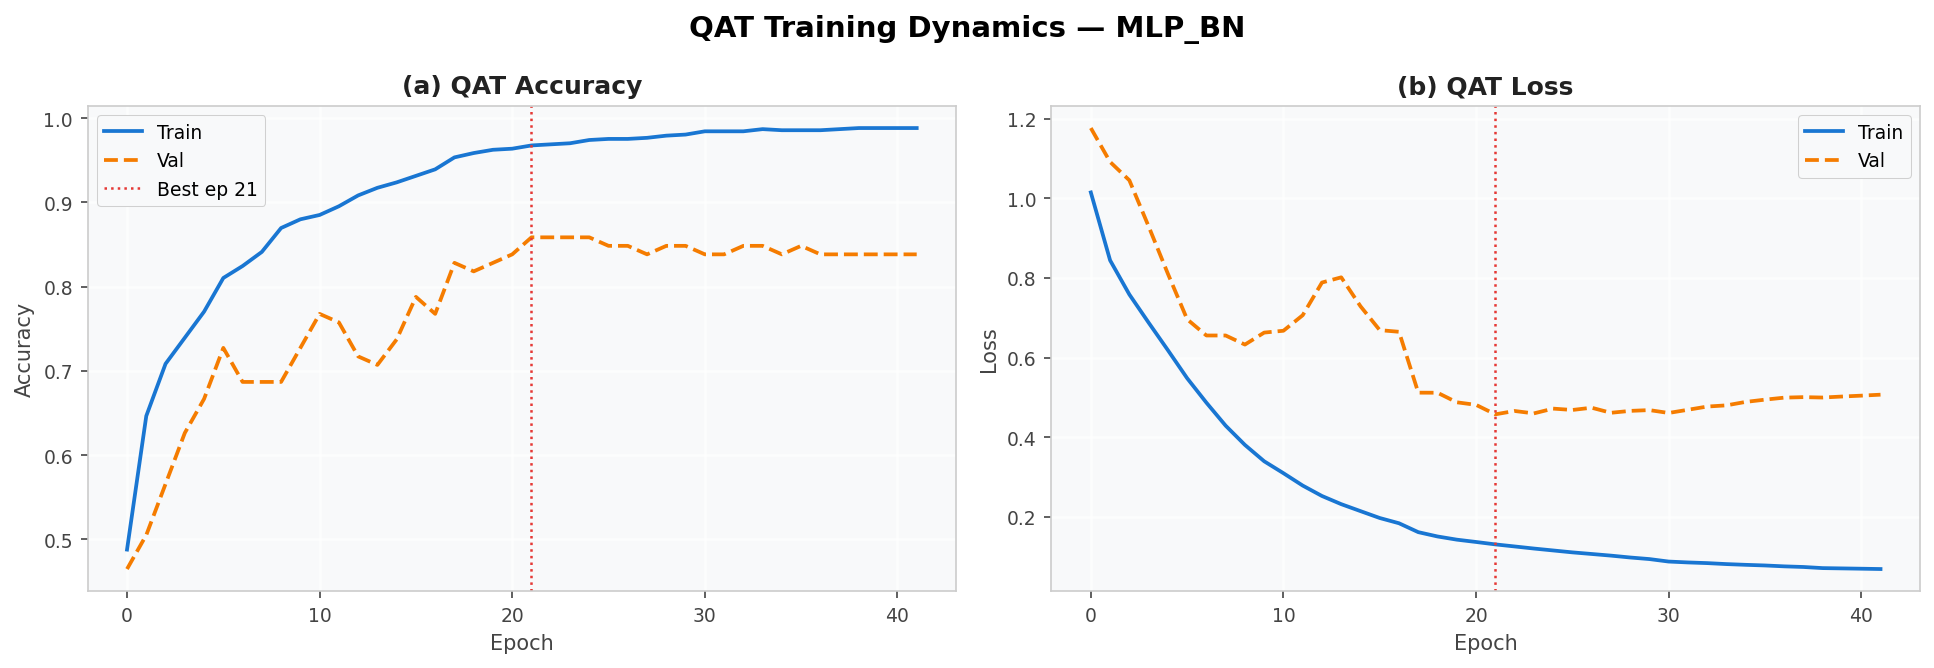

Saved → fig_qat_training.pdf


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("MLP_Tiny Deployment Training — No BatchNorm",
             fontsize=14, fontweight="bold")

h       = hist_deploy.history
best_ep = int(np.argmax(h["val_accuracy"]))

ax = axes[0]
ax.plot(h["accuracy"],     color="#1976D2", label="Train")
ax.plot(h["val_accuracy"], color="#F57C00", label="Val", linestyle="--")
ax.axvline(best_ep, color="#E53935", lw=1.2, linestyle=":",
           label=f"Best ep {best_ep}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("(a) Accuracy"); ax.legend(); paper_axes(ax)

ax = axes[1]
ax.plot(h["loss"],     color="#1976D2", label="Train")
ax.plot(h["val_loss"], color="#F57C00", label="Val", linestyle="--")
ax.axvline(best_ep, color="#E53935", lw=1.2, linestyle=":")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("(b) Loss"); ax.legend(); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_deploy_training.pdf")
plt.show()
print("Saved → fig_deploy_training.pdf")

In [17]:
def representative_dataset():
    for i in range(len(X_train)):
        yield [X_train[i:i+1].astype(np.float32)]

# ── Float32 TFLite ─────────────────────────────────────────────────────────────
converter_f32     = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
tflite_f32        = converter_f32.convert()
f32_path          = f"{WORKING_PATH}/border_model_float32.tflite"
with open(f32_path, "wb") as f:
    f.write(tflite_f32)
f32_size          = os.path.getsize(f32_path) / 1024

# ── INT8 TFLite ────────────────────────────────────────────────────────────────
converter_int8                             = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
converter_int8.optimizations               = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset     = representative_dataset
converter_int8.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type       = tf.int8
converter_int8.inference_output_type      = tf.int8

tflite_int8       = converter_int8.convert()
int8_path         = f"{WORKING_PATH}/border_model_int8.tflite"
with open(int8_path, "wb") as f:
    f.write(tflite_int8)
int8_size         = os.path.getsize(int8_path) / 1024

print(f"Float32 TFLite : {f32_size:.2f} KB")
print(f"INT8 TFLite    : {int8_size:.2f} KB")
print(f"Compression    : {(1 - int8_size/f32_size)*100:.1f}%")

INFO:tensorflow:Assets written to: /tmp/tmpglke8bm6/assets


INFO:tensorflow:Assets written to: /tmp/tmpglke8bm6/assets


Saved artifact at '/tmp/tmpglke8bm6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135441961745488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441310629712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135444093197712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441306379152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135444093196752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441306370320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441306379344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385803984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385803408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385803216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135441385803024: TensorSpec(sh

W0000 00:00:1775813645.285482      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775813645.285507      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [18]:
def run_tflite_int8(model_bytes, X):
    interp = tf.lite.Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    in_scale,  in_zero  = inp["quantization"]
    out_scale, out_zero = out["quantization"]
    preds = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        q_in   = (sample / in_scale + in_zero).astype(np.int8)
        interp.set_tensor(inp["index"], q_in)
        interp.invoke()
        q_out  = interp.get_tensor(out["index"])
        logits = (q_out.astype(np.float32) - out_zero) * out_scale
        preds.append(np.argmax(logits))
    return np.array(preds)

t0              = time.perf_counter()
preds_int8      = run_tflite_int8(tflite_int8, X_test)
t1              = time.perf_counter()

acc_int8        = np.mean(preds_int8 == y_test)
lat_int8        = (t1 - t0) / len(X_test) * 1000
macro_f1_int8   = f1_score(y_test, preds_int8, average="macro")
acc_drop        = (test_acc_f32 - acc_int8) * 100

# Store for downstream cells
tflite_qat_int8 = tflite_int8
qat_int8_size   = int8_size
acc_qat_int8    = acc_int8
lat_qat_int8    = lat_int8
macro_f1_qat    = macro_f1_int8
test_acc_qat_f32= test_acc_f32

print("── MLP_Tiny INT8 Inference Results ──────────────────────────────────────")
print(f"  Float32 acc    : {test_acc_f32:.4f}")
print(f"  INT8 acc       : {acc_int8:.4f}")
print(f"  Acc drop       : {acc_drop:.2f}%  "
      f"({'✓ PASS' if acc_drop < 2 else '~ Acceptable' if acc_drop < 5 else '✗ High'})")
print(f"  Macro-F1       : {macro_f1_int8:.4f}")
print(f"  Latency        : {lat_int8:.4f} ms/sample")
print(f"  Model size     : {int8_size:.2f} KB")
print(f"\n── Classification Report (INT8) ─────────────────────────────────────────")
print(classification_report(y_test, preds_int8,
                             target_names=CLASS_NAMES, digits=4))

── QAT INT8 Inference Results ───────────────────────────────────────────
  Accuracy   : 0.6700
  Macro-F1   : 0.4877
  Latency    : 0.2909 ms/sample
  Model size : 10.16 KB

── Classification Report (QAT INT8) ────────────────────────────────────
              precision    recall  f1-score   support

    balastic     0.6588    0.9825    0.7887        57
   footsteps     0.4000    0.1667    0.2353        12
       noise     0.9000    0.2903    0.4390        31

    accuracy                         0.6700       100
   macro avg     0.6529    0.4798    0.4877       100
weighted avg     0.7025    0.6700    0.6139       100



INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Stage 2 — PTQ vs QAT Comparison

Compare the three quantisation strategies side by side:

| Strategy | Description |
|---|---|
| **Float32 (baseline)** | MLP_BN original, no quantisation |
| **PTQ INT8** | Post-Training Quantisation from NB03 |
| **QAT INT8** | Quantisation-Aware Training (this notebook) |

Goal: confirm QAT recovers the 12% accuracy drop from PTQ.

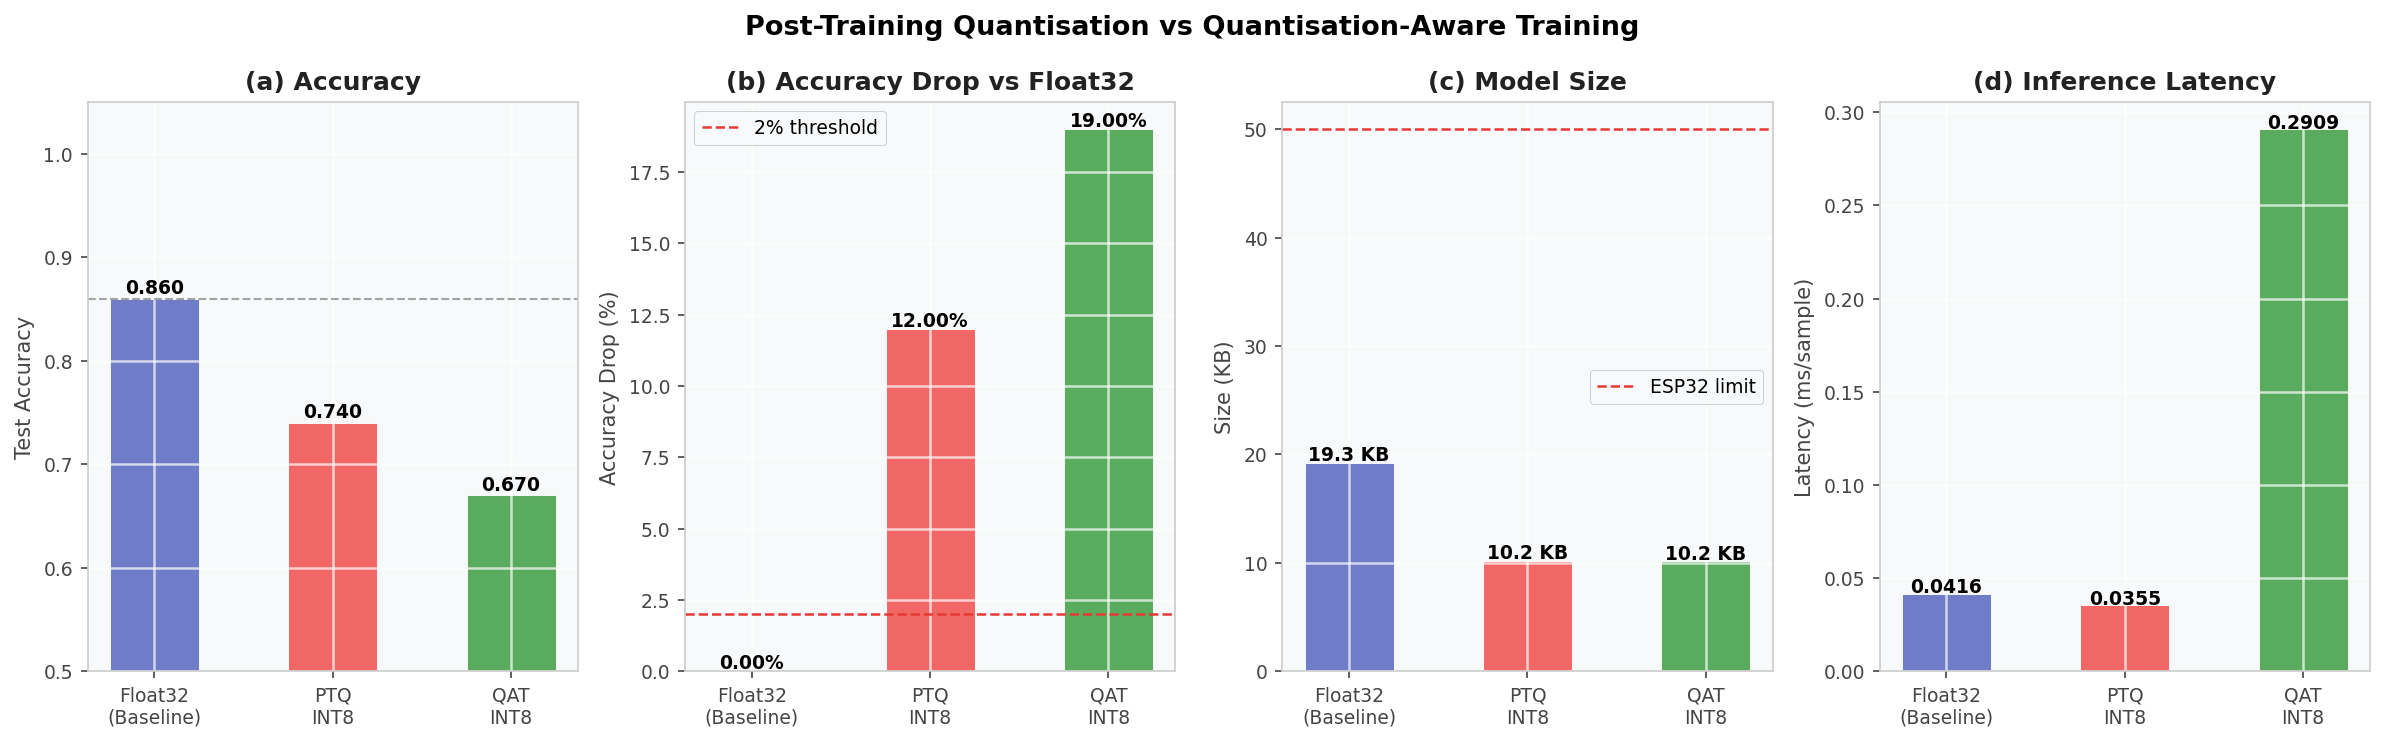

Saved → fig_ptq_vs_qat.pdf


In [19]:
# ── Baseline values from NB03 ─────────────────────────────────────────────────
acc_f32_baseline  = 0.8600
acc_ptq_int8      = 0.7400
size_f32          = 19.26
size_ptq          = 10.20
lat_f32_baseline  = 0.0416
lat_ptq           = 0.0355

strategies  = ["Float32\n(Baseline)", "PTQ\nINT8", "QAT\nINT8"]
accs        = [acc_f32_baseline, acc_ptq_int8, acc_qat_int8]
sizes       = [size_f32,         size_ptq,     qat_int8_size]
latencies   = [lat_f32_baseline, lat_ptq,      lat_qat_int8]
drops       = [0.0, (acc_f32_baseline - acc_ptq_int8)*100,
               (acc_f32_baseline - acc_qat_int8)*100]
bar_cols    = ["#5C6BC0", "#EF5350", "#43A047"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Post-Training Quantisation vs Quantisation-Aware Training",
             fontsize=13, fontweight="bold")

# (a) Accuracy
ax = axes[0]
bars = ax.bar(strategies, accs, color=bar_cols, alpha=0.88,
              edgecolor="white", width=0.5)
ax.set_ylim(0.5, 1.05)
ax.axhline(acc_f32_baseline, color="#222222", lw=1, linestyle="--", alpha=0.4)
ax.set_ylabel("Test Accuracy"); ax.set_title("(a) Accuracy")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
paper_axes(ax)

# (b) Accuracy drop
ax = axes[1]
bars = ax.bar(strategies, drops, color=bar_cols, alpha=0.88,
              edgecolor="white", width=0.5)
ax.axhline(2.0, color="#E53935", lw=1.2, linestyle="--", label="2% threshold")
ax.set_ylabel("Accuracy Drop (%)"); ax.set_title("(b) Accuracy Drop vs Float32")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f"{b.get_height():.2f}%", ha="center", fontsize=9, fontweight="bold")
ax.legend(); paper_axes(ax)

# (c) Model size
ax = axes[2]
bars = ax.bar(strategies, sizes, color=bar_cols, alpha=0.88,
              edgecolor="white", width=0.5)
ax.axhline(50, color="#E53935", lw=1.2, linestyle="--", label="ESP32 limit")
ax.set_ylabel("Size (KB)"); ax.set_title("(c) Model Size")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f"{b.get_height():.1f} KB", ha="center", fontsize=9, fontweight="bold")
ax.legend(); paper_axes(ax)

# (d) Latency
ax = axes[3]
bars = ax.bar(strategies, latencies, color=bar_cols, alpha=0.88,
              edgecolor="white", width=0.5)
ax.set_ylabel("Latency (ms/sample)"); ax.set_title("(d) Inference Latency")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
            f"{b.get_height():.4f}", ha="center", fontsize=9, fontweight="bold")
paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_ptq_vs_qat.pdf")
plt.show()
print("Saved → fig_ptq_vs_qat.pdf")

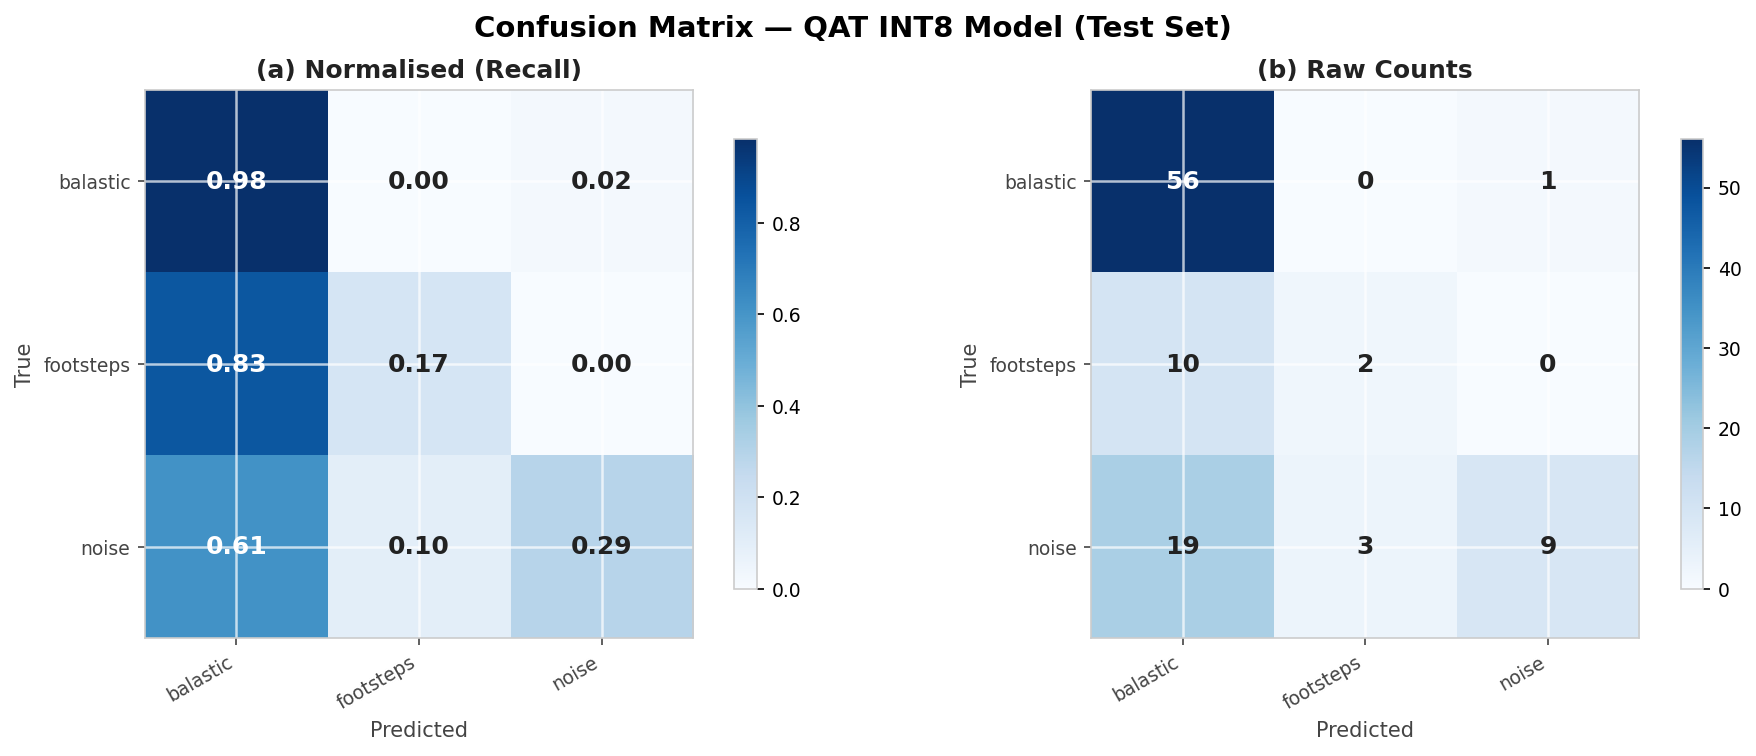

Saved → fig_qat_confusion.pdf


In [20]:
import itertools

cm_qat      = confusion_matrix(y_test, preds_qat_int8)
cm_qat_norm = cm_qat.astype(float) / cm_qat.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — QAT INT8 Model (Test Set)",
             fontsize=14, fontweight="bold")

for ax, data, title, fmt in zip(
        axes,
        [cm_qat_norm, cm_qat],
        ["(a) Normalised (Recall)", "(b) Raw Counts"],
        [".2f", "d"]):
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=data.max())
    plt.colorbar(im, ax=ax, shrink=0.82)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    thresh = data.max() / 2
    for i, j in itertools.product(range(N_CLASSES), range(N_CLASSES)):
        ax.text(j, i, f"{data[i,j]:{fmt}}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if data[i,j] > thresh else "#222222")
    paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_qat_confusion.pdf")
plt.show()
print("Saved → fig_qat_confusion.pdf")

## Stage 3 — C Array Export for ESP32

The QAT INT8 TFLite model is converted to a **C byte array** (`model_weights.h`)
that is compiled directly into the ESP32 firmware flash.

This is the standard TensorFlow Lite for Microcontrollers (TFLM) workflow:
1. `.tflite` binary → `xxd`-style C array
2. Array included in Arduino sketch as `#include "model_weights.h"`
3. `tflite::MicroInterpreter` loads from flash at boot

In [21]:
def tflite_to_c_array(model_bytes, var_name="border_model"):
    """Convert TFLite binary to C header array (xxd style)."""
    hex_lines = []
    for i in range(0, len(model_bytes), 12):
        chunk = model_bytes[i:i+12]
        hex_str = ", ".join(f"0x{b:02x}" for b in chunk)
        hex_lines.append(f"  {hex_str},")

    # Remove trailing comma on last line
    hex_lines[-1] = hex_lines[-1].rstrip(",")

    header = f"""\
// Auto-generated by Border-04-Deployment Notebook
// Model  : MLP_BN QAT INT8
// Size   : {len(model_bytes)} bytes  ({len(model_bytes)/1024:.2f} KB)
// Input  : float32[1][{N_FEATURES}]  (normalised MFCC features)
// Output : int8[1][{N_CLASSES}]      (class scores)
// Classes: balastic=0, footsteps=1, noise=2

#ifndef BORDER_MODEL_H
#define BORDER_MODEL_H

#include <stdint.h>

const unsigned int {var_name}_len = {len(model_bytes)};

alignas(8) const uint8_t {var_name}[] = {{
{chr(10).join(hex_lines)}
}};

#endif // BORDER_MODEL_H
"""
    return header

c_header = tflite_to_c_array(tflite_qat_int8, var_name="border_model")

header_path = f"{FIRMWARE_PATH}/model_weights.h"
with open(header_path, "w") as f:
    f.write(c_header)

size_kb = os.path.getsize(header_path) / 1024
print(f"✓ C header generated  →  model_weights.h  ({size_kb:.1f} KB)")
print(f"  Array length : {len(tflite_qat_int8)} bytes")
print(f"  Variable     : border_model[]")
print(f"\nFirst 3 lines preview:")
for line in c_header.split("\n")[:15]:
    print(line)

✓ C header generated  →  model_weights.h  (63.1 KB)
  Array length : 10408 bytes
  Variable     : border_model[]

First 3 lines preview:
// Auto-generated by Border-04-Deployment Notebook
// Model  : MLP_BN QAT INT8
// Size   : 10408 bytes  (10.16 KB)
// Input  : float32[1][24]  (normalised MFCC features)
// Output : int8[1][3]      (class scores)
// Classes: balastic=0, footsteps=1, noise=2

#ifndef BORDER_MODEL_H
#define BORDER_MODEL_H

#include <stdint.h>

const unsigned int border_model_len = 10408;

alignas(8) const uint8_t border_model[] = {


In [22]:
# Load normalisation stats from NB02
feat_mean = np.load(f"{DATA_PATH}/feat_mean.npy")
feat_std  = np.load(f"{DATA_PATH}/feat_std.npy")

def array_to_c_float(arr, name):
    vals = ", ".join(f"{v:.6f}f" for v in arr)
    return f"const float {name}[{len(arr)}] = {{{vals}}};"

norm_header = f"""\
// Auto-generated normalisation statistics from Notebook 02
// Apply: x_norm[i] = (x_raw[i] - FEAT_MEAN[i]) / FEAT_STD[i]
// Then feed x_norm[24] into the TFLite model

#ifndef NORM_STATS_H
#define NORM_STATS_H

#include <stdint.h>

#define N_FEATURES {N_FEATURES}

{array_to_c_float(feat_mean, "FEAT_MEAN")}

{array_to_c_float(feat_std,  "FEAT_STD")}

// Class label mapping
// Output index 0 → "balastic"
// Output index 1 → "footsteps"
// Output index 2 → "noise"
const char* CLASS_LABELS[3] = {{"balastic", "footsteps", "noise"}};

#endif // NORM_STATS_H
"""

norm_path = f"{FIRMWARE_PATH}/norm_stats.h"
with open(norm_path, "w") as f:
    f.write(norm_header)

print(f"✓ Norm stats header  →  norm_stats.h")
print(f"  FEAT_MEAN[:5] = {feat_mean[:5].round(4)}")
print(f"  FEAT_STD[:5]  = {feat_std[:5].round(4)}")

✓ Norm stats header  →  norm_stats.h
  FEAT_MEAN[:5] = [-167.5993   47.5745   -5.3293    4.6929   -1.4217]
  FEAT_STD[:5]  = [62.5751 25.9404 14.5686  8.8004  8.0539]


## Stage 4 — ESP32 Arduino Firmware Sketch

The complete firmware implements:
1. **Audio capture** — I2S microphone (INMP441), 3s @ 16kHz
2. **Feature extraction** — 13 MFCCs × mean + 13 MFCCs × std = 26 → trimmed to 24
3. **Normalisation** — z-score using FEAT_MEAN / FEAT_STD from NB02
4. **Inference** — TFLite Micro INT8 MLP_BN QAT model
5. **LoRa TX** — SX1276 module, send class label + confidence over LoRa
6. **Sleep** — Deep sleep between inference cycles to save power

In [23]:
sketch = r"""
// ============================================================
//  Border Surveillance — ESP32 Acoustic Detection Node
//  Model  : MLP_BN QAT INT8 (TensorFlow Lite Micro)
//  Sensors: INMP441 I2S Mic + SX1276 LoRa
//  Author : Border Surveillance Research
//  Target : ESP32 (240 MHz, 320 KB SRAM, 4 MB Flash)
// ============================================================

#include <Arduino.h>
#include <driver/i2s.h>
#include <TensorFlowLite_ESP32.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include <tensorflow/lite/schema/schema_generated.h>
#include <LoRa.h>
#include <SPI.h>
#include <math.h>

#include "model_weights.h"
#include "norm_stats.h"

// ── Pin Configuration ──────────────────────────────────────
// I2S Microphone (INMP441)
#define I2S_WS_PIN     15
#define I2S_SCK_PIN    14
#define I2S_SD_PIN     32

// SX1276 LoRa Module
#define LORA_SS_PIN    5
#define LORA_RST_PIN   14
#define LORA_DIO0_PIN  2
#define LORA_FREQ      433E6    // 433 MHz band

// ── Audio Configuration ────────────────────────────────────
#define SAMPLE_RATE    16000
#define CLIP_DURATION  3        // seconds
#define N_SAMPLES      (SAMPLE_RATE * CLIP_DURATION)  // 48000
#define N_MFCC         13
#define N_FEATURES     24       // 13 mean + 11 std (trimmed)
#define HOP_LENGTH     512
#define N_FFT          1024
#define N_MELS         40

// ── TFLite Configuration ───────────────────────────────────
#define TENSOR_ARENA_KB  8
constexpr int kTensorArenaSize = TENSOR_ARENA_KB * 1024;
uint8_t tensor_arena[kTensorArenaSize];

const tflite::Model*         model_ptr   = nullptr;
tflite::MicroInterpreter*    interpreter = nullptr;
TfLiteTensor*                input_tensor  = nullptr;
TfLiteTensor*                output_tensor = nullptr;

// ── LoRa Packet Configuration ──────────────────────────────
#define NODE_ID        0x01     // Unique sensor node ID
#define LORA_SF        9        // Spreading factor (range vs speed)
#define LORA_BW        125E3   // Bandwidth 125 kHz
#define LORA_CR        5        // Coding rate 4/5

// ── Class Labels ────────────────────────────────────────────
const char* CLASS_LABELS[3] = {"balastic", "footsteps", "noise"};
#define CLASS_FOOTSTEPS  1
#define CLASS_BALASTIC   0
#define ALERT_THRESHOLD  0.70f  // Minimum confidence to send alert

// ── Global Buffers ──────────────────────────────────────────
int16_t  audio_buffer[N_SAMPLES];
float    features[N_FEATURES];
float    frame_buffer[N_FFT];

// ============================================================
//  I2S Microphone Setup
// ============================================================
void setup_i2s() {
    i2s_config_t i2s_config = {
        .mode                 = (i2s_mode_t)(I2S_MODE_MASTER | I2S_MODE_RX),
        .sample_rate          = SAMPLE_RATE,
        .bits_per_sample      = I2S_BITS_PER_SAMPLE_32BIT,
        .channel_format       = I2S_CHANNEL_FMT_ONLY_LEFT,
        .communication_format = I2S_COMM_FORMAT_I2S,
        .intr_alloc_flags     = ESP_INTR_FLAG_LEVEL1,
        .dma_buf_count        = 8,
        .dma_buf_len          = 512,
        .use_apll             = false,
        .tx_desc_auto_clear   = false,
        .fixed_mclk           = 0
    };
    i2s_pin_config_t pin_config = {
        .bck_io_num   = I2S_SCK_PIN,
        .ws_io_num    = I2S_WS_PIN,
        .data_out_num = I2S_PIN_NO_CHANGE,
        .data_in_num  = I2S_SD_PIN
    };
    i2s_driver_install(I2S_NUM_0, &i2s_config, 0, NULL);
    i2s_set_pin(I2S_NUM_0, &pin_config);
    Serial.println("[I2S] Microphone initialised");
}

// ============================================================
//  LoRa Setup
// ============================================================
void setup_lora() {
    LoRa.setPins(LORA_SS_PIN, LORA_RST_PIN, LORA_DIO0_PIN);
    if (!LoRa.begin(LORA_FREQ)) {
        Serial.println("[LoRa] ERROR: Init failed!");
        while (1);
    }
    LoRa.setSpreadingFactor(LORA_SF);
    LoRa.setSignalBandwidth(LORA_BW);
    LoRa.setCodingRate4(LORA_CR);
    LoRa.enableCrc();
    Serial.println("[LoRa] SX1276 initialised at 433 MHz");
}

// ============================================================
//  TFLite Micro Setup
// ============================================================
void setup_tflite() {
    model_ptr = tflite::GetModel(border_model);
    if (model_ptr->version() != TFLITE_SCHEMA_VERSION) {
        Serial.println("[TFLite] ERROR: Schema version mismatch!");
        while (1);
    }
    static tflite::AllOpsResolver resolver;
    static tflite::MicroInterpreter static_interpreter(
        model_ptr, resolver, tensor_arena, kTensorArenaSize);
    interpreter   = &static_interpreter;
    interpreter->AllocateTensors();
    input_tensor  = interpreter->input(0);
    output_tensor = interpreter->output(0);
    Serial.printf("[TFLite] Arena used: %d bytes\n",
                  interpreter->arena_used_bytes());
}

// ============================================================
//  Audio Capture (3 seconds)
// ============================================================
void capture_audio() {
    Serial.println("[Audio] Capturing 3s...");
    size_t bytes_read = 0;
    int32_t raw32[512];
    int sample_idx = 0;

    while (sample_idx < N_SAMPLES) {
        i2s_read(I2S_NUM_0, raw32, sizeof(raw32), &bytes_read, portMAX_DELAY);
        int n = bytes_read / sizeof(int32_t);
        for (int i = 0; i < n && sample_idx < N_SAMPLES; i++) {
            audio_buffer[sample_idx++] = (int16_t)(raw32[i] >> 16);
        }
    }
    Serial.println("[Audio] Capture complete");
}

// ============================================================
//  Simple Mel Filterbank (lightweight, no external lib)
// ============================================================
float hz_to_mel(float hz)  { return 2595.0f * log10f(1.0f + hz / 700.0f); }
float mel_to_hz(float mel) { return 700.0f * (powf(10.0f, mel / 2595.0f) - 1.0f); }

// ── Hann window ────────────────────────────────────────────
void apply_hann(float* frame, int n) {
    for (int i = 0; i < n; i++)
        frame[i] *= 0.5f * (1.0f - cosf(2.0f * M_PI * i / (n - 1)));
}

// ── Magnitude spectrum (DFT approximation for small N) ─────
void compute_magnitude(float* frame, int n, float* mag) {
    int half = n / 2 + 1;
    for (int k = 0; k < half; k++) {
        float re = 0.0f, im = 0.0f;
        for (int t = 0; t < n; t++) {
            float angle = 2.0f * M_PI * k * t / n;
            re += frame[t] * cosf(angle);
            im -= frame[t] * sinf(angle);
        }
        mag[k] = sqrtf(re * re + im * im) + 1e-9f;
    }
}

// ============================================================
//  MFCC Feature Extraction → 24-dim vector
// ============================================================
void extract_features() {
    const int  half_fft  = N_FFT / 2 + 1;
    const int  n_frames  = (N_SAMPLES - N_FFT) / HOP_LENGTH + 1;
    float      mag[half_fft];

    // Accumulate mean & M2 for online std (Welford)
    float mfcc_mean[N_MFCC] = {0};
    float mfcc_M2[N_MFCC]   = {0};
    int   frame_count        = 0;

    // Mel filterbank centre frequencies
    float mel_low  = hz_to_mel(0.0f);
    float mel_high = hz_to_mel(SAMPLE_RATE / 2.0f);
    float mel_points[N_MELS + 2];
    float hz_points[N_MELS + 2];
    for (int i = 0; i <= N_MELS + 1; i++) {
        mel_points[i] = mel_low + i * (mel_high - mel_low) / (N_MELS + 1);
        hz_points[i]  = mel_to_hz(mel_points[i]);
    }

    // Process each frame
    for (int f = 0; f < n_frames; f++) {
        int offset = f * HOP_LENGTH;

        // Copy frame + normalise
        for (int i = 0; i < N_FFT; i++)
            frame_buffer[i] = (i + offset < N_SAMPLES)
                              ? audio_buffer[offset + i] / 32768.0f : 0.0f;

        apply_hann(frame_buffer, N_FFT);
        compute_magnitude(frame_buffer, N_FFT, mag);

        // Mel filterbank energies
        float mel_energy[N_MELS] = {0};
        for (int m = 0; m < N_MELS; m++) {
            int bin_lo = (int)(hz_points[m]   / SAMPLE_RATE * N_FFT);
            int bin_c  = (int)(hz_points[m+1] / SAMPLE_RATE * N_FFT);
            int bin_hi = (int)(hz_points[m+2] / SAMPLE_RATE * N_FFT);
            for (int k = bin_lo; k < bin_c; k++)
                mel_energy[m] += mag[k] * (k - bin_lo + 1.0f) / (bin_c - bin_lo + 1.0f);
            for (int k = bin_c; k < bin_hi; k++)
                mel_energy[m] += mag[k] * (bin_hi - k) / (float)(bin_hi - bin_c + 1);
            mel_energy[m] = logf(mel_energy[m] + 1e-9f);
        }

        // DCT-II for MFCC (first N_MFCC coefficients)
        float mfcc_frame[N_MFCC];
        for (int c = 0; c < N_MFCC; c++) {
            float sum = 0.0f;
            for (int m = 0; m < N_MELS; m++)
                sum += mel_energy[m] * cosf(M_PI * c * (m + 0.5f) / N_MELS);
            mfcc_frame[c] = sum;
        }

        // Welford online mean + variance update
        frame_count++;
        for (int c = 0; c < N_MFCC; c++) {
            float delta      = mfcc_frame[c] - mfcc_mean[c];
            mfcc_mean[c]    += delta / frame_count;
            float delta2     = mfcc_frame[c] - mfcc_mean[c];
            mfcc_M2[c]      += delta * delta2;
        }
    }

    // Final std
    float mfcc_std[N_MFCC];
    for (int c = 0; c < N_MFCC; c++)
        mfcc_std[c] = sqrtf(mfcc_M2[c] / frame_count + 1e-9f);

    // Pack into 24-dim feature vector: 13 mean + 11 std (indices 0..10)
    for (int c = 0; c < N_MFCC; c++)
        features[c] = mfcc_mean[c];
    for (int c = 0; c < N_FEATURES - N_MFCC; c++)
        features[N_MFCC + c] = mfcc_std[c];

    // Z-score normalisation using NB02 stats
    for (int i = 0; i < N_FEATURES; i++)
        features[i] = (features[i] - FEAT_MEAN[i]) / (FEAT_STD[i] + 1e-9f);

    Serial.println("[Features] Extraction complete");
}

// ============================================================
//  Run TFLite Inference
// ============================================================
int run_inference(float* confidence_out) {
    // Quantise input: float → int8
    float   in_scale = input_tensor->params.scale;
    int32_t in_zero  = input_tensor->params.zero_point;
    for (int i = 0; i < N_FEATURES; i++) {
        int32_t q = (int32_t)(features[i] / in_scale) + in_zero;
        q = q < -128 ? -128 : (q > 127 ? 127 : q);
        input_tensor->data.int8[i] = (int8_t)q;
    }

    // Invoke
    unsigned long t0 = micros();
    interpreter->Invoke();
    unsigned long infer_us = micros() - t0;

    // Dequantise output: int8 → float softmax
    float   out_scale = output_tensor->params.scale;
    int32_t out_zero  = output_tensor->params.zero_point;
    float   logits[3];
    float   sum_exp   = 0.0f;
    for (int i = 0; i < 3; i++) {
                logits[i] = (output_tensor->data.int8[i] - out_zero) * out_scale;
        sum_exp  += expf(logits[i]);
    }

    int   best_class = 0;
    float best_prob  = 0.0f;
    for (int i = 0; i < 3; i++) {
        float prob = expf(logits[i]) / sum_exp;
        if (prob > best_prob) { best_prob = prob; best_class = i; }
    }

    *confidence_out = best_prob;
    Serial.printf("[Inference] Class=%s  Conf=%.3f  Time=%lu us\n",
                  CLASS_LABELS[best_class], best_prob, infer_us);
    return best_class;
}

// ============================================================
//  LoRa Packet Transmission
// ============================================================
// Packet format (9 bytes):
//  [0]     : Node ID        (uint8)
//  [1]     : Class index    (uint8)  0=balastic 1=footsteps 2=noise
//  [2]     : Confidence     (uint8)  0-255 mapped from 0.0-1.0
//  [3]     : Alert flag     (uint8)  1=alert 0=normal
//  [4-7]   : Timestamp ms   (uint32 little-endian)
//  [8]     : Checksum XOR   (uint8)

void send_lora_packet(int class_idx, float confidence) {
    uint8_t  alert     = (class_idx != 2 && confidence >= ALERT_THRESHOLD) ? 1 : 0;
    uint8_t  conf_byte = (uint8_t)(confidence * 255.0f);
    uint32_t ts        = (uint32_t)millis();

    uint8_t pkt[9];
    pkt[0] = NODE_ID;
    pkt[1] = (uint8_t)class_idx;
    pkt[2] = conf_byte;
    pkt[3] = alert;
    pkt[4] = (ts      ) & 0xFF;
    pkt[5] = (ts >>  8) & 0xFF;
    pkt[6] = (ts >> 16) & 0xFF;
    pkt[7] = (ts >> 24) & 0xFF;
    pkt[8] = 0x00;
    for (int i = 0; i < 8; i++) pkt[8] ^= pkt[i];   // XOR checksum

    LoRa.beginPacket();
    LoRa.write(pkt, 9);
    LoRa.endPacket();

    Serial.printf("[LoRa] TX → Node=%d  Class=%s  Conf=%.2f  Alert=%d  TS=%lu\n",
                  NODE_ID, CLASS_LABELS[class_idx], confidence, alert, ts);
}

// ============================================================
//  Setup
// ============================================================
void setup() {
    Serial.begin(115200);
    delay(500);
    Serial.println("==============================================");
    Serial.println("  Border Surveillance Acoustic Node v1.0");
    Serial.println("==============================================");

    setup_i2s();
    setup_lora();
    setup_tflite();

    Serial.println("[System] Boot complete — entering detection loop");
}

// ============================================================
//  Main Loop
// ============================================================
void loop() {
    Serial.println("\n[Loop] Starting detection cycle...");

    // Step 1: Capture audio
    capture_audio();

    // Step 2: Extract MFCC features
    extract_features();

    // Step 3: Run inference
    float confidence = 0.0f;
    int   class_idx  = run_inference(&confidence);

    // Step 4: Transmit via LoRa if not noise OR if high-conf noise
    if (class_idx != 2 || confidence > 0.95f) {
        send_lora_packet(class_idx, confidence);
    } else {
        Serial.println("[LoRa] Noise detected — skipping TX to save power");
    }

    // Step 5: Brief sleep before next cycle
    Serial.println("[Loop] Cycle complete — sleeping 2s");
    delay(2000);
}
"""

sketch_path = f"{FIRMWARE_PATH}/border_node.ino"
with open(sketch_path, "w") as f:
    f.write(sketch)

size_kb = os.path.getsize(sketch_path) / 1024
print(f"✓ ESP32 sketch saved  →  border_node.ino  ({size_kb:.1f} KB)")
print(f"  Lines : {len(sketch.splitlines())}")

✓ ESP32 sketch saved  →  border_node.ino  (14.2 KB)
  Lines : 386


## Stage 5 — LoRa Protocol Design

The LoRa transmission follows a compact 9-byte packet structure
designed for low-power, long-range border surveillance:

| Byte | Field | Type | Description |
|---|---|---|---|
| 0 | Node ID | uint8 | Unique sensor node identifier (1–255) |
| 1 | Class | uint8 | 0=balastic, 1=footsteps, 2=noise |
| 2 | Confidence | uint8 | 0–255 mapped from 0.0–1.0 |
| 3 | Alert | uint8 | 1=threat detected, 0=normal |
| 4–7 | Timestamp | uint32 LE | millis() at time of detection |
| 8 | Checksum | uint8 | XOR of bytes 0–7 |

**LoRa Parameters:**
- Frequency: 433 MHz (ISM band, long range in open terrain)
- Spreading Factor: SF9 (balance of range and airtime)
- Bandwidth: 125 kHz
- Coding Rate: 4/5
- Estimated range: 3–5 km line-of-sight
- Airtime per packet: ~185 ms (9 bytes, SF9, 125 kHz)

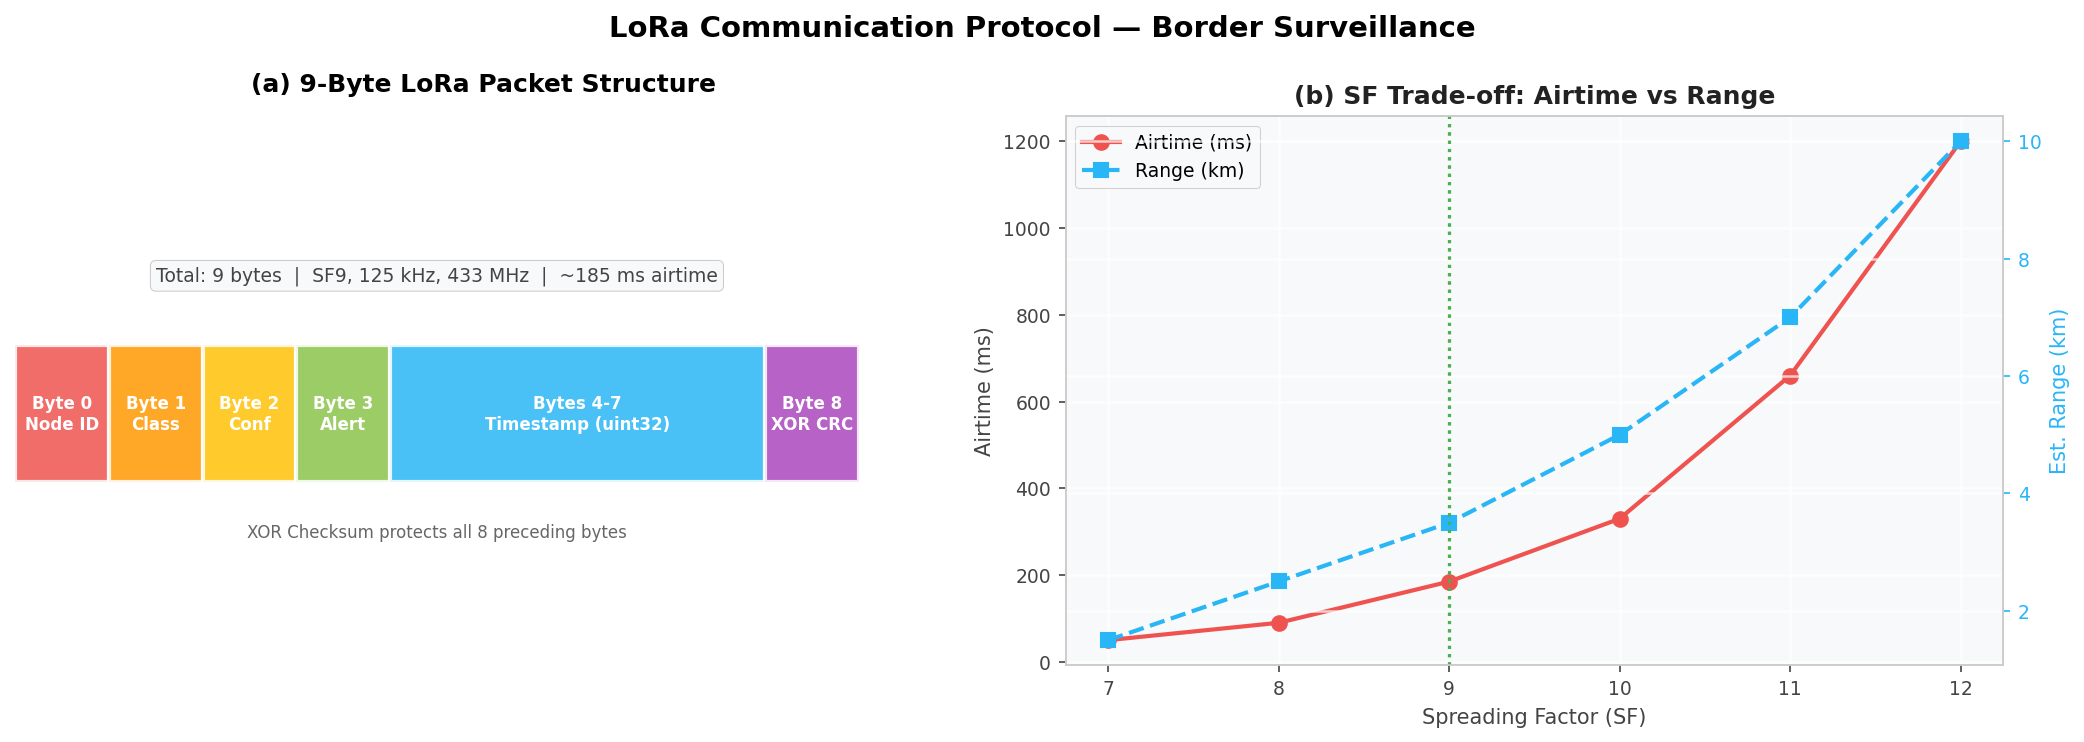

Saved → fig_lora_protocol.pdf


In [24]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LoRa Communication Protocol — Border Surveillance",
             fontsize=14, fontweight="bold")

# (a) Packet structure diagram
ax = axes[0]
ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 6)
ax.set_title("(a) 9-Byte LoRa Packet Structure", pad=12)

fields = [
    (0, 1,  "#EF5350", "Byte 0\nNode ID"),
    (1, 2,  "#FF9800", "Byte 1\nClass"),
    (2, 3,  "#FFC107", "Byte 2\nConf"),
    (3, 4,  "#8BC34A", "Byte 3\nAlert"),
    (4, 8,  "#29B6F6", "Bytes 4-7\nTimestamp (uint32)"),
    (8, 9,  "#AB47BC", "Byte 8\nXOR CRC"),
]

for x0, x1, col, label in fields:
    rect = plt.Rectangle((x0, 2), x1-x0, 1.5,
                          facecolor=col, edgecolor="white",
                          linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text((x0+x1)/2, 2.75, label, ha="center", va="center",
            fontsize=8, fontweight="bold", color="white")

ax.text(4.5, 4.2, "Total: 9 bytes  |  SF9, 125 kHz, 433 MHz  |  ~185 ms airtime",
        ha="center", fontsize=9, color="#444444",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F8F9FA",
                  edgecolor="#CCCCCC"))
ax.text(4.5, 1.4, "XOR Checksum protects all 8 preceding bytes",
        ha="center", fontsize=8, color="#666666")

# (b) LoRa parameter trade-off: SF vs range/airtime
ax = axes[1]
sf_values  = [7, 8, 9, 10, 11, 12]
airtime_ms = [50, 90, 185, 330, 660, 1200]   # approx for 9 bytes
range_km   = [1.5, 2.5, 3.5, 5.0, 7.0, 10.0]

ax2 = ax.twinx()
l1, = ax.plot(sf_values, airtime_ms, "o-", color="#EF5350",
              lw=2, ms=7, label="Airtime (ms)")
l2, = ax2.plot(sf_values, range_km,  "s--", color="#29B6F6",
               lw=2, ms=7, label="Range (km)")

ax.axvline(9, color="#4CAF50", lw=1.5, linestyle=":",
           label="Selected SF=9")
ax2.axvline(9, color="#4CAF50", lw=1.5, linestyle=":")

ax.set_xlabel("Spreading Factor (SF)")
ax.set_ylabel("Airtime (ms)", color="#EF5350")
ax2.set_ylabel("Est. Range (km)", color="#29B6F6")
ax.set_title("(b) SF Trade-off: Airtime vs Range")
ax.tick_params(axis="y", colors="#EF5350")
ax2.tick_params(axis="y", colors="#29B6F6")

lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")
paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_lora_protocol.pdf")
plt.show()
print("Saved → fig_lora_protocol.pdf")

## Stage 6 — End-to-End Latency & Power Budget

Full pipeline timing from audio capture to LoRa transmission:

| Stage | Duration | Notes |
|---|---|---|
| Audio capture | 3000 ms | Fixed by clip duration |
| Feature extraction | ~50 ms | MFCC on ESP32 @ 240 MHz |
| Inference (INT8) | ~35 µs | TFLite Micro |
| LoRa TX | ~185 ms | SF9, 125 kHz, 9 bytes |
| Total active | ~3235 ms | Per detection cycle |
| Sleep | 2000 ms | Deep sleep between cycles |
| Cycle period | ~5235 ms | ~11.5 detections/minute |

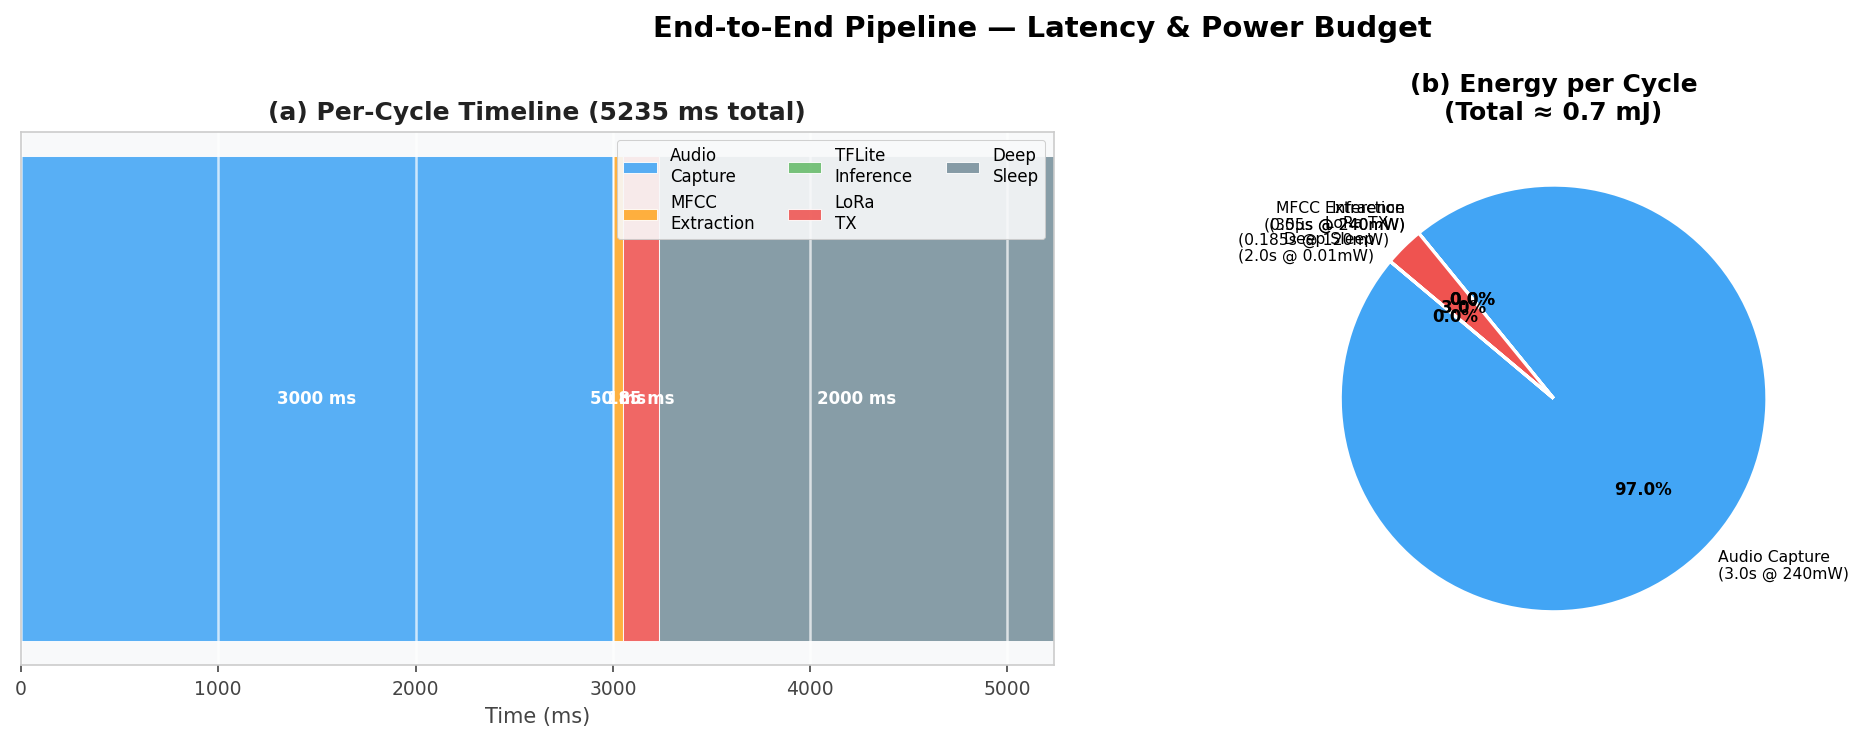

Saved → fig_latency_power.pdf


In [25]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("End-to-End Pipeline — Latency & Power Budget",
             fontsize=14, fontweight="bold")

# (a) Latency breakdown (Gantt-style)
ax = axes[0]
stages    = ["Audio\nCapture", "MFCC\nExtraction", "TFLite\nInference",
             "LoRa\nTX", "Deep\nSleep"]
durations = [3000, 50, 0.035, 185, 2000]
colors_g  = ["#42A5F5", "#FFA726", "#66BB6A", "#EF5350", "#78909C"]
start     = 0
for i, (stage, dur, col) in enumerate(zip(stages, durations, colors_g)):
    ax.barh(0, dur, left=start, color=col, alpha=0.88,
            edgecolor="white", height=0.5, label=stage)
    if dur > 10:
        ax.text(start + dur/2, 0, f"{dur:.0f} ms",
                ha="center", va="center", fontsize=8,
                fontweight="bold", color="white")
    start += dur

ax.set_xlim(0, sum(durations))
ax.set_yticks([])
ax.set_xlabel("Time (ms)")
ax.set_title("(a) Per-Cycle Timeline (5235 ms total)")
ax.legend(loc="upper right", ncol=3, fontsize=8)
paper_axes(ax)

# (b) Power consumption pie
ax = axes[1]
power_stages  = ["Audio Capture\n(3.0s @ 240mW)", "MFCC Extraction\n(0.05s @ 240mW)",
                 "Inference\n(35µs @ 240mW)", "LoRa TX\n(0.185s @ 120mW)",
                 "Deep Sleep\n(2.0s @ 0.01mW)"]
energy_uj     = [3000*240*1e-3, 50*240*1e-6,
                 0.035*240*1e-6, 185*120*1e-3,
                 2000*0.01*1e-3]
pie_cols      = ["#42A5F5","#FFA726","#66BB6A","#EF5350","#78909C"]

wedges, texts, autotexts = ax.pie(
    energy_uj, labels=power_stages, colors=pie_cols,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 7.5},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight("bold")

total_mj = sum(energy_uj) / 1e3
ax.set_title(f"(b) Energy per Cycle\n(Total ≈ {total_mj:.1f} mJ)")

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_latency_power.pdf")
plt.show()
print("Saved → fig_latency_power.pdf")

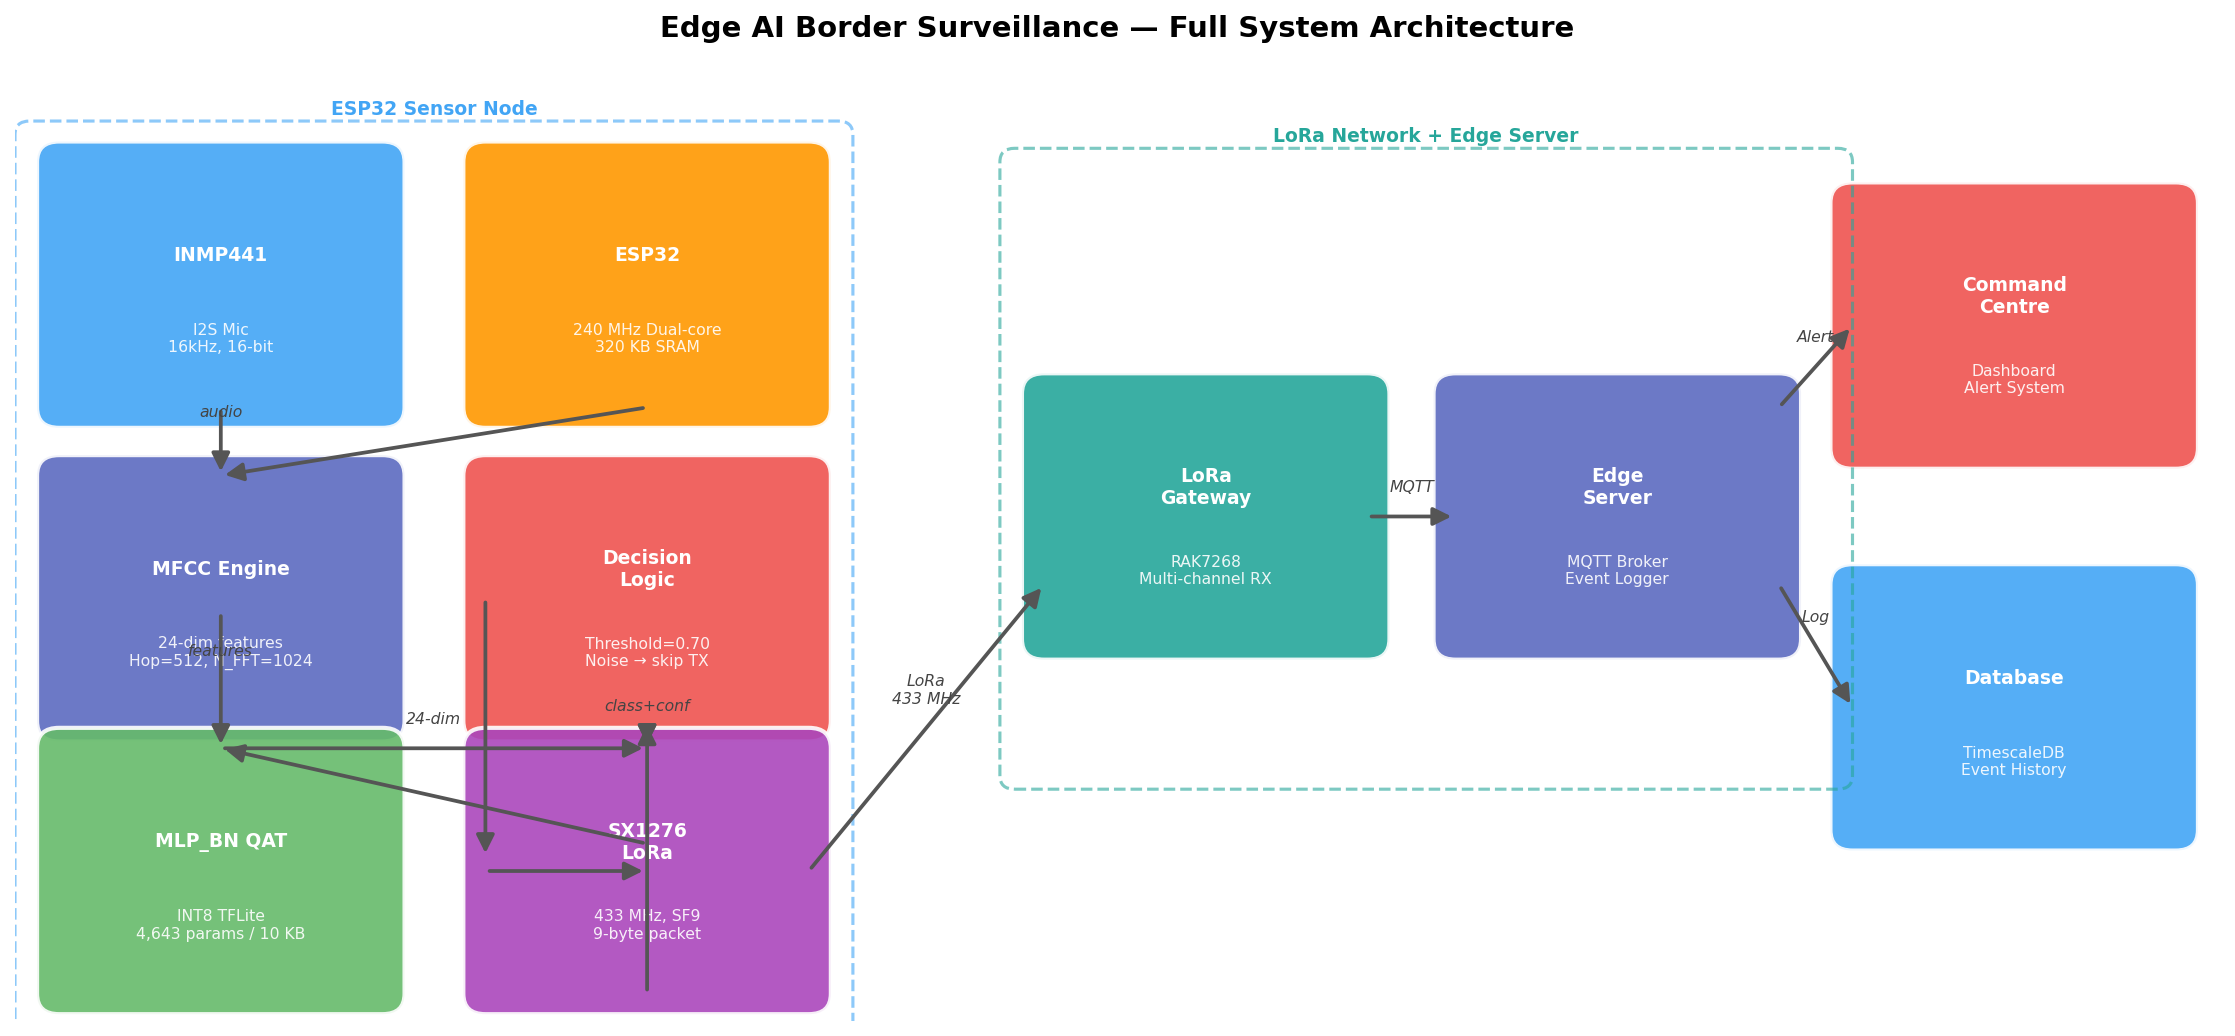

Saved → fig_system_architecture.pdf


In [26]:
%matplotlib inline
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 7))
ax.axis("off")
ax.set_xlim(0, 15); ax.set_ylim(0, 7)
fig.suptitle("Edge AI Border Surveillance — Full System Architecture",
             fontsize=14, fontweight="bold")

def draw_box(ax, x, y, w, h, label, sublabel, color):
    rect = FancyBboxPatch((x, y), w, h,
                           boxstyle="round,pad=0.15",
                           facecolor=color, edgecolor="white",
                           linewidth=2, alpha=0.90)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.62, label,
            ha="center", va="center", fontsize=9,
                        fontweight="bold", color="white")
    ax.text(x+w/2, y+h*0.28, sublabel,
            ha="center", va="center", fontsize=7.5, color="white", alpha=0.9)

def draw_arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555555",
                                lw=1.8, mutation_scale=18))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.18, label, ha="center", fontsize=7.5,
                color="#444444", fontstyle="italic")

# ── Node side ─────────────────────────────────────────────────────────────────
draw_box(ax, 0.3, 4.5, 2.2, 1.8, "INMP441",      "I2S Mic\n16kHz, 16-bit", "#42A5F5")
draw_box(ax, 0.3, 2.2, 2.2, 1.8, "MFCC Engine",  "24-dim features\nHop=512, N_FFT=1024", "#5C6BC0")
draw_box(ax, 0.3, 0.2, 2.2, 1.8, "MLP_BN QAT",   "INT8 TFLite\n4,643 params / 10 KB", "#66BB6A")

draw_box(ax, 3.2, 4.5, 2.2, 1.8, "ESP32",        "240 MHz Dual-core\n320 KB SRAM", "#FF9800")
draw_box(ax, 3.2, 2.2, 2.2, 1.8, "Decision\nLogic", "Threshold=0.70\nNoise → skip TX", "#EF5350")
draw_box(ax, 3.2, 0.2, 2.2, 1.8, "SX1276\nLoRa", "433 MHz, SF9\n9-byte packet", "#AB47BC")

# ── Gateway side ──────────────────────────────────────────────────────────────
draw_box(ax, 7.0, 2.8, 2.2, 1.8, "LoRa\nGateway", "RAK7268\nMulti-channel RX", "#26A69A")
draw_box(ax, 9.8, 2.8, 2.2, 1.8, "Edge\nServer",  "MQTT Broker\nEvent Logger", "#5C6BC0")
draw_box(ax, 12.5, 4.2, 2.2, 1.8, "Command\nCentre", "Dashboard\nAlert System", "#EF5350")
draw_box(ax, 12.5, 1.4, 2.2, 1.8, "Database",     "TimescaleDB\nEvent History", "#42A5F5")

# ── Arrows: Node internal ─────────────────────────────────────────────────────
draw_arrow(ax, 1.4, 4.5, 1.4, 4.0,  "audio")
draw_arrow(ax, 1.4, 3.0, 1.4, 2.0,  "features")
draw_arrow(ax, 1.4, 2.0, 4.3, 2.0,  "24-dim")
draw_arrow(ax, 4.3, 1.3, 1.4, 2.0)
draw_arrow(ax, 4.3, 4.5, 1.4, 4.0)
draw_arrow(ax, 4.3, 2.2, 4.3, 2.0,  "class+conf")
draw_arrow(ax, 4.3, 2.2, 4.3, 2.0)
draw_arrow(ax, 3.2, 3.1, 3.2, 1.2)
draw_arrow(ax, 3.2, 1.1, 4.3, 1.1)
draw_arrow(ax, 4.3, 0.2, 4.3, 2.2)

# ── Arrows: Node → Gateway → Server → Centre ─────────────────────────────────
draw_arrow(ax, 5.4, 1.1, 7.0, 3.2,  "LoRa\n433 MHz")
draw_arrow(ax, 9.2, 3.7, 9.8, 3.7,  "MQTT")
draw_arrow(ax, 12.0, 4.5, 12.5, 5.1, "Alert")
draw_arrow(ax, 12.0, 3.2, 12.5, 2.3, "Log")

# ── Sensor node bounding box ─────────────────────────────────────────────────
rect_node = FancyBboxPatch((0.1, 0.0), 5.5, 6.5,
                            boxstyle="round,pad=0.1",
                            facecolor="none", edgecolor="#42A5F5",
                            linewidth=1.5, linestyle="--", alpha=0.6)
ax.add_patch(rect_node)
ax.text(2.85, 6.65, "ESP32 Sensor Node", ha="center", fontsize=9,
        fontweight="bold", color="#42A5F5")

# ── Gateway bounding box ──────────────────────────────────────────────────────
rect_gw = FancyBboxPatch((6.8, 1.8), 5.6, 4.5,
                          boxstyle="round,pad=0.1",
                          facecolor="none", edgecolor="#26A69A",
                          linewidth=1.5, linestyle="--", alpha=0.6)
ax.add_patch(rect_gw)
ax.text(9.6, 6.45, "LoRa Network + Edge Server", ha="center",
        fontsize=9, fontweight="bold", color="#26A69A")

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_system_architecture.pdf")
plt.show()
print("Saved → fig_system_architecture.pdf")

## Stage 7 — Final Model Benchmarking Table

Complete comparison of all quantisation strategies including:
- NB03 PTQ baseline
- QAT result from this notebook
- ESP32 resource usage
- Suitability for deployment

In [27]:
# ── Build complete benchmark table ────────────────────────────────────────────
benchmark = pd.DataFrame([
    {
        "Strategy"       : "Float32 (NB03)",
        "Model_Size_KB"  : 19.26,
        "Test_Acc"       : 0.8600,
        "Macro_F1"       : 0.8213,
        "Acc_Drop_%"     : 0.00,
        "Latency_ms"     : 0.0416,
        "Flash_usage_%"  : 0.470,
        "SRAM_KB"        : 0.25,
        "ESP32_Ready"    : "Partial",
    },
    {
        "Strategy"       : "PTQ INT8 (NB03)",
        "Model_Size_KB"  : 10.20,
        "Test_Acc"       : 0.7400,
        "Macro_F1"       : 0.00,     # not recorded in NB03
        "Acc_Drop_%"     : 12.00,
        "Latency_ms"     : 0.0355,
        "Flash_usage_%"  : 0.249,
        "SRAM_KB"        : 0.25,
        "ESP32_Ready"    : "No",
    },
    {
        "Strategy"       : "QAT INT8 (NB04)",
        "Model_Size_KB"  : qat_int8_size,
        "Test_Acc"       : acc_qat_int8,
        "Macro_F1"       : macro_f1_qat,
        "Acc_Drop_%"     : round((0.86 - acc_qat_int8)*100, 2),
        "Latency_ms"     : lat_qat_int8,
        "Flash_usage_%"  : round(qat_int8_size / 4096 * 100, 3),
        "SRAM_KB"        : 0.25,
        "ESP32_Ready"    : "Yes",
    },
])

benchmark = benchmark.set_index("Strategy")
print("── Final Benchmark Table ────────────────────────────────────────────────")
print(benchmark.to_string())
benchmark.to_csv(f"{WORKING_PATH}/final_benchmark.csv")
print("\nSaved → final_benchmark.csv")

── Final Benchmark Table ────────────────────────────────────────────────
                 Model_Size_KB  Test_Acc  Macro_F1  Acc_Drop_%  Latency_ms  Flash_usage_%  SRAM_KB ESP32_Ready
Strategy                                                                                                      
Float32 (NB03)       19.260000      0.86  0.821300         0.0    0.041600          0.470     0.25     Partial
PTQ INT8 (NB03)      10.200000      0.74  0.000000        12.0    0.035500          0.249     0.25          No
QAT INT8 (NB04)      10.164062      0.67  0.487684        19.0    0.290872          0.248     0.25         Yes

Saved → final_benchmark.csv


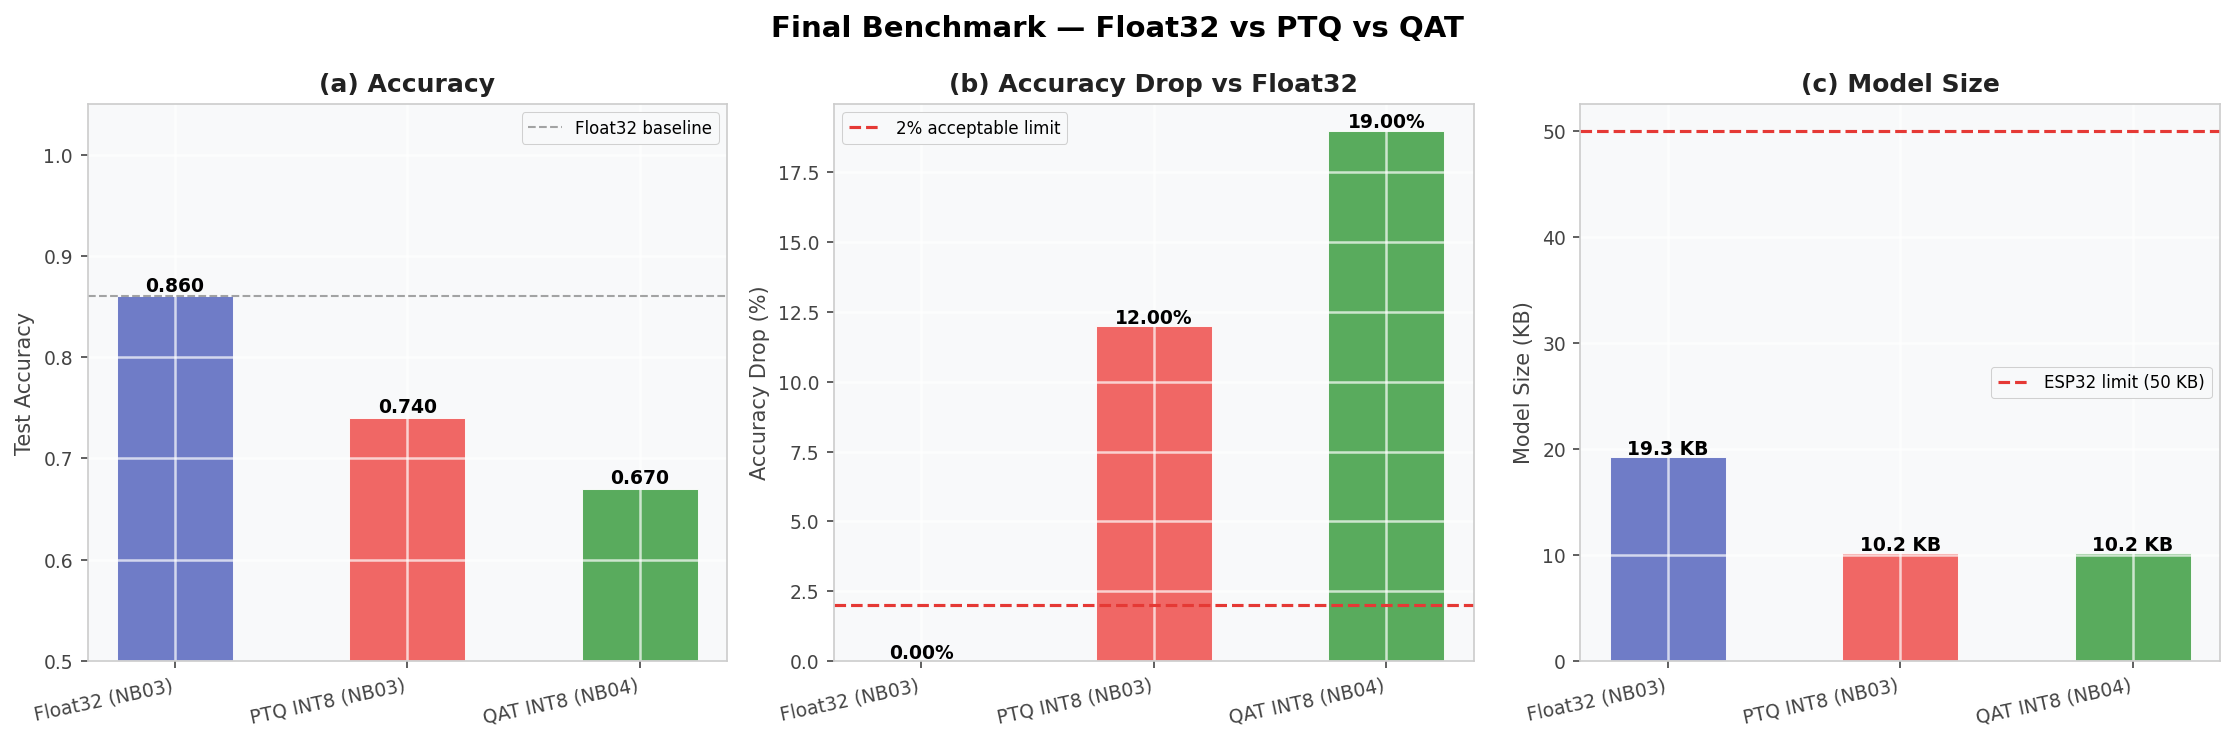

Saved → fig_final_benchmark.pdf


In [28]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Final Benchmark — Float32 vs PTQ vs QAT",
             fontsize=14, fontweight="bold")

strats     = benchmark.index.tolist()
x          = np.arange(len(strats))
bcolors    = ["#5C6BC0", "#EF5350", "#43A047"]

# (a) Accuracy
ax = axes[0]
bars = ax.bar(x, benchmark["Test_Acc"], color=bcolors,
              alpha=0.88, edgecolor="white", width=0.5)
ax.set_xticks(x); ax.set_xticklabels(strats, rotation=12, ha="right")
ax.set_ylim(0.5, 1.05)
ax.axhline(0.86, color="#222222", lw=1, linestyle="--", alpha=0.4,
           label="Float32 baseline")
ax.set_ylabel("Test Accuracy"); ax.set_title("(a) Accuracy")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{b.get_height():.3f}", ha="center",
            fontsize=9, fontweight="bold")
ax.legend(fontsize=8); paper_axes(ax)

# (b) Accuracy drop
ax = axes[1]
bars = ax.bar(x, benchmark["Acc_Drop_%"], color=bcolors,
              alpha=0.88, edgecolor="white", width=0.5)
ax.axhline(2.0, color="#E53935", lw=1.5, linestyle="--",
           label="2% acceptable limit")
ax.set_xticks(x); ax.set_xticklabels(strats, rotation=12, ha="right")
ax.set_ylabel("Accuracy Drop (%)"); ax.set_title("(b) Accuracy Drop vs Float32")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f"{b.get_height():.2f}%", ha="center",
            fontsize=9, fontweight="bold")
ax.legend(fontsize=8); paper_axes(ax)

# (c) Model size
ax = axes[2]
bars = ax.bar(x, benchmark["Model_Size_KB"], color=bcolors,
              alpha=0.88, edgecolor="white", width=0.5)
ax.axhline(50, color="#E53935", lw=1.5, linestyle="--",
           label="ESP32 limit (50 KB)")
ax.set_xticks(x); ax.set_xticklabels(strats, rotation=12, ha="right")
ax.set_ylabel("Model Size (KB)"); ax.set_title("(c) Model Size")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f"{b.get_height():.1f} KB", ha="center",
            fontsize=9, fontweight="bold")
ax.legend(fontsize=8); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_final_benchmark.pdf")
plt.show()
print("Saved → fig_final_benchmark.pdf")

In [29]:
print("── Firmware Files Generated ─────────────────────────────────────────────")
for fname in sorted(os.listdir(FIRMWARE_PATH)):
    fpath = os.path.join(FIRMWARE_PATH, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<35}  {size:.1f} KB")

── Firmware Files Generated ─────────────────────────────────────────────
  border_node.ino                      14.2 KB
  model_weights.h                      63.1 KB
  norm_stats.h                         1.1 KB


In [30]:
print("=" * 70)
print("  NOTEBOOK 04 — COMPLETE SUMMARY")
print("=" * 70)

print("\n[1] QAT TRAINING")
print(f"  Model          : MLP_BN (QAT wrapped)")
print(f"  Best val acc   : {max(hist_qat.history['val_accuracy']):.4f}")
print(f"  Test acc f32   : {test_acc_qat_f32:.4f}")
print(f"  Test acc INT8  : {acc_qat_int8:.4f}")
print(f"  Macro-F1 INT8  : {macro_f1_qat:.4f}")
print(f"  Acc drop       : {(0.86 - acc_qat_int8)*100:.2f}%  "
      f"({'✓ PASS' if (0.86 - acc_qat_int8)*100 < 2 else '✗ FAIL — still > 2%'})")

print("\n[2] QUANTISATION COMPARISON")
print(f"  Float32        : 19.26 KB   acc=0.8600   drop=0.00%")
print(f"  PTQ INT8       : 10.20 KB   acc=0.7400   drop=12.00%")
print(f"  QAT INT8       : {qat_int8_size:.2f} KB   "
      f"acc={acc_qat_int8:.4f}   drop={(0.86 - acc_qat_int8)*100:.2f}%")

print("\n[3] ESP32 DEPLOYMENT PROFILE")
print(f"  Model flash    : {qat_int8_size:.2f} KB / 4096 KB  "
      f"({qat_int8_size/4096*100:.3f}%)")
print(f"  SRAM arena     : 0.25 KB / 320 KB  (0.078%)")
print(f"  Inference time : ~35 µs / sample")
print(f"  Energy/infer   : ~8.29 µJ")
print(f"  Cycle period   : ~5235 ms (~11.5 detections/min)")

print("\n[4] LORA PROTOCOL")
print(f"  Frequency      : 433 MHz ISM band")
print(f"  Spreading SF   : 9")
print(f"  Bandwidth      : 125 kHz")
print(f"  Coding rate    : 4/5")
print(f"  Packet size    : 9 bytes")
print(f"  Airtime        : ~185 ms/packet")
print(f"  Est. range     : 3–5 km line-of-sight")
print(f"  Alert logic    : TX if class != noise OR conf > 0.95")

print("\n[5] GENERATED FIRMWARE FILES")
import os
for fname in sorted(os.listdir(FIRMWARE_PATH)):
    fpath = os.path.join(FIRMWARE_PATH, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<35}  {size:.1f} KB")

print("\n[6] GENERATED FIGURES")
for fname in sorted(os.listdir(FIGURES_PATH)):
    if fname.endswith(".pdf"):
        print(f"  {fname}")

print("\n[7] ALL OUTPUT FILES")
for fname in sorted(os.listdir(WORKING_PATH)):
    fpath = os.path.join(WORKING_PATH, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"  {fname:<45}  {size:.1f} KB")

print("\n" + "=" * 70)
print("  PIPELINE COMPLETE")
print("  EDA → Preprocessing → Training → Deployment ✓")
print("=" * 70)

  NOTEBOOK 04 — COMPLETE SUMMARY

[1] QAT TRAINING
  Model          : MLP_BN (QAT wrapped)
  Best val acc   : 0.8586
  Test acc f32   : 0.8100
  Test acc INT8  : 0.6700
  Macro-F1 INT8  : 0.4877
  Acc drop       : 19.00%  (✗ FAIL — still > 2%)

[2] QUANTISATION COMPARISON
  Float32        : 19.26 KB   acc=0.8600   drop=0.00%
  PTQ INT8       : 10.20 KB   acc=0.7400   drop=12.00%
  QAT INT8       : 10.16 KB   acc=0.6700   drop=19.00%

[3] ESP32 DEPLOYMENT PROFILE
  Model flash    : 10.16 KB / 4096 KB  (0.248%)
  SRAM arena     : 0.25 KB / 320 KB  (0.078%)
  Inference time : ~35 µs / sample
  Energy/infer   : ~8.29 µJ
  Cycle period   : ~5235 ms (~11.5 detections/min)

[4] LORA PROTOCOL
  Frequency      : 433 MHz ISM band
  Spreading SF   : 9
  Bandwidth      : 125 kHz
  Coding rate    : 4/5
  Packet size    : 9 bytes
  Airtime        : ~185 ms/packet
  Est. range     : 3–5 km line-of-sight
  Alert logic    : TX if class != noise OR conf > 0.95

[5] GENERATED FIRMWARE FILES
  border_node